# Average Shortest Paths Notebook (Using CRSP Data)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from ts2vg import HorizontalVG, NaturalVG

In [9]:
NUM_COL = 'prc'
DATE_COL = 'date'
TICKER_COL = 'permno'

In [ ]:
data = pd.read_csv('./data/crsp_dsf.csv')
data[DATE_COL] = data[DATE_COL].astype('datetime64[s]')
data = data.dropna(subset=NUM_COL).reset_index(drop=True)
data.head()

,permno,date,bidlo,askhi,prc,vol,ret,retx,bid,ask,shrout,cfacpr,cfacshr,openprc,numtrd
0,10001,2010-01-04,10.10,10.5800,10.25,18500.0,-0.004854,-0.004854,10.21,10.26,4361.0,1.0,1.0,10.58,NaN
1,10001,2010-01-05,9.80,10.3600,10.19,23200.0,-0.005854,-0.005854,10.15,10.19,4361.0,1.0,1.0,10.18,NaN
2,10001,2010-01-06,10.15,10.4800,10.31,18700.0,0.011776,0.011776,10.31,10.35,4361.0,1.0,1.0,10.18,NaN
3,10001,2010-01-07,9.91,10.3695,9.96,29200.0,-0.033948,-0.033948,9.95,9.97,4361.0,1.0,1.0,10.28,NaN
4,10001,2010-01-08,10.00,10.4000,10.34,25100.0,0.038153,0.038153,10.34,10.37,4361.0,1.0,1.0,10.00,NaN


In [10]:
tickers = data[TICKER_COL].unique()

In [24]:
TICKER = tickers[29]

In [12]:
### avsp ==> Average Shortest Path
def ts2vg_shortest_path_features(arr, lookback):
    avsp_p = np.zeros(len(arr))
    avsp_n = np.zeros(len(arr))

    avsp_p[:] = np.nan
    avsp_n[:] = np.nan

    for i in range(lookback, len(arr)):
        dat = arr[i - lookback + 1: i+1]

        pos = NaturalVG()
        pos.build(dat)

        neg = NaturalVG()
        neg.build(-dat)

        neg = neg.as_networkx()
        pos = pos.as_networkx()
        
        avsp_p[i] = nx.average_shortest_path_length(pos)
        avsp_n[i] = nx.average_shortest_path_length(neg)

    return avsp_p, avsp_n

In [25]:
df = data[data[TICKER_COL] == TICKER].copy()
### Subset for initial testing
df = df.iloc[:200, :]
df = df.sort_values(DATE_COL).set_index(DATE_COL)

In [27]:
lookback = 7
arr = df[NUM_COL].to_numpy()

### Get shortest path features
pos, neg = ts2vg_shortest_path_features(arr, lookback)

df["pos"] = pos
df["neg"] = neg
df = df.dropna().reset_index()

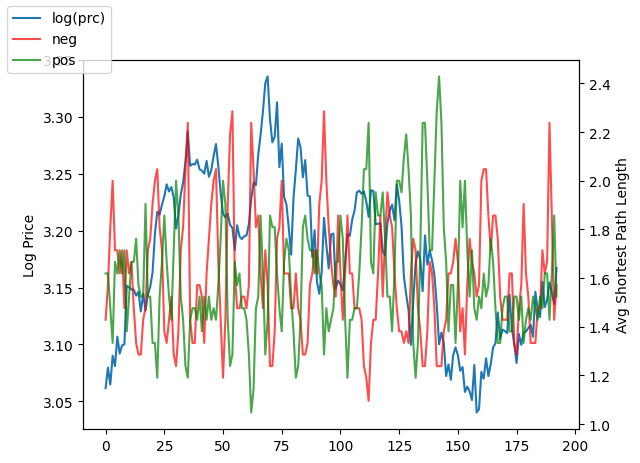

In [28]:
fig, ax1 = plt.subplots()

ax1.plot(np.log(df[NUM_COL]), label=f"log({NUM_COL})")
ax1.set_ylabel("Log Price")

ax2 = ax1.twinx()
ax2.plot(df["neg"], color="red", label="neg", alpha=0.7)
ax2.plot(df["pos"], color="green", label="pos", alpha=0.7)
ax2.set_ylabel("Avg Shortest Path Length")

fig.legend(loc="upper left")
plt.show()

In [29]:
def get_avsp_one_stock(ticker, data=data, lookback=7, num_col=NUM_COL, ret_cols = [DATE_COL, TICKER_COL, 'pos', 'neg']):
    df = data[data[TICKER_COL] == ticker].copy()
    df = df.sort_values(DATE_COL).set_index(DATE_COL)
    arr = df[num_col].to_numpy()

    ### Get shortest path features
    pos, neg = ts2vg_shortest_path_features(arr, lookback)

    df["pos"] = pos
    df["neg"] = neg
    df = df.dropna().reset_index()
    
    cols = ret_cols + [num_col]

    return df[cols]

In [30]:
def get_all_avsp(tickers=tickers, data=data, lookback=7, num_col=NUM_COL, ret_cols = [DATE_COL, TICKER_COL, 'pos', 'neg']):
    all_avsp = pd.DataFrame()
    
    for t in tickers:
        avsp_df = get_avsp_one_stock(ticker=t, data=data, lookback=lookback, num_col=num_col, ret_cols=ret_cols)
        
        if len(all_avsp) == 0:
            all_avsp = avsp_df.copy()
        else:
            all_avsp = pd.concat([all_avsp, avsp_df])
    
    return all_avsp

In [ ]:
lookback=7
all_avsp = get_all_avsp(tickers=tickers, lookback=7)
all_avsp.to_csv(f"./data/all_avsp_crsp_window_{lookback}.csv", index=False)

In [33]:
all_avsp.head()

,date,permno,pos,neg,prc
0,2010-01-13,10002,1.476190,1.714286,2.82
1,2010-01-14,10002,1.476190,1.619048,2.85
2,2010-01-15,10002,1.333333,1.809524,2.89
3,2010-01-19,10002,1.333333,1.571429,2.74
4,2010-01-20,10002,1.476190,1.476190,2.85
